# Arabic Reviews Sentiment Analysis

## Data Loading

In [1]:
import pandas as pd

reviews = pd.read_csv('data/CompanyReviews.csv')

reviews.head()

,Unnamed: 0,review_description,rating,company
0,0,رائع,1,talbat
1,1,برنامج رائع جدا يساعد على تلبيه الاحتياجات بشك...,1,talbat
2,2,التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال با...,-1,talbat
3,3,لماذا لا يمكننا طلب من ماكدونالدز؟,-1,talbat
4,4,البرنامج بيظهر كل المطاعم و مغلقه مع انها بتكو...,-1,talbat


In [2]:
reviews.drop(columns=['Unnamed: 0', 'company'], inplace=True)

reviews.head()

,review_description,rating
0,رائع,1
1,برنامج رائع جدا يساعد على تلبيه الاحتياجات بشك...,1
2,التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال با...,-1
3,لماذا لا يمكننا طلب من ماكدونالدز؟,-1
4,البرنامج بيظهر كل المطاعم و مغلقه مع انها بتكو...,-1


## EDA

In [3]:
reviews['rating'].unique()

array([ 1, -1,  0])

In [4]:
for i in range(10):
    print(reviews['review_description'][i], reviews['rating'][i])

رائع 1
برنامج رائع جدا يساعد على تلبيه الاحتياجات بشكل اسرع 1
التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال بالشبكة..مع انه النت عندي تمام شو الحل?? -1
لماذا لا يمكننا طلب من ماكدونالدز؟ -1
البرنامج بيظهر كل المطاعم و مغلقه مع انها بتكون فاتحه بقاله كده اكتر من شهر -1
أصبح غالي جداً -1
جميل جدا رائع. . . 1
للأسف الواحد ينصدم بعد زيادة الاسعار و للاسف بعض المطاعم اصبحت معاملتهم رديئة -1
برنامج توترز توصيل احلى من برنامجكم فاشل -1
كتير في تحسن خدمة العملاء لطفين في بعض الاخطاء التقنية لكن بتصلحوها بسرعة وبعض التاخير سياسيتكم وتسويقكم صار افضل من كريم بالنسبة الي متفقين 1


In [5]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40046 entries, 0 to 40045
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   review_description  40045 non-null  object
 1   rating              40046 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 625.8+ KB


In [6]:
reviews['review_description'].isna().value_counts()

review_description
False    40045
True         1
Name: count, dtype: int64

In [7]:
reviews.dropna(inplace=True)

reviews['review_description'].isna().value_counts()

review_description
False    40045
Name: count, dtype: int64

In [8]:
len(reviews[reviews['rating'] == 0])

1925

In [9]:
reviews = reviews[reviews['rating'] != 0]

reviews.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38120 entries, 0 to 40042
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   review_description  38120 non-null  object
 1   rating              38120 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 893.4+ KB


In [10]:
import numpy as np

reviews['rating'] = np.where(reviews['rating'] == -1, 0, 1)

reviews.head()

,review_description,rating
0,رائع,1
1,برنامج رائع جدا يساعد على تلبيه الاحتياجات بشك...,1
2,التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال با...,0
3,لماذا لا يمكننا طلب من ماكدونالدز؟,0
4,البرنامج بيظهر كل المطاعم و مغلقه مع انها بتكو...,0


## Data Splitting

In [11]:
target = 'rating'

X = reviews['review_description']
y = reviews[target]

X.shape, y.shape

((38120,), (38120,))

In [12]:
from sklearn.model_selection import train_test_split

X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=42)

X_train.shape, X_val.shape, X_test.shape

((24396,), (6100,), (7624,))

## Training

In [13]:
import tensorflow as tf

text_vec_layer = tf.keras.layers.TextVectorization(1000)
text_vec_layer.adapt(X_train)

In [14]:
model = tf.keras.Sequential([
    text_vec_layer,
    tf.keras.layers.Embedding(1000, 5),
    tf.keras.layers.LSTM(128),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [15]:
model.compile(
    loss='binary_crossentropy',
    optimizer='nadam',
    metrics=['accuracy'],
)

In [16]:
history = model.fit(
    X_train.values, y_train.values,
    validation_data=(X_val.values, y_val.values),
    epochs=10,
)

Epoch 1/10
763/763 ━━━━━━━━━━━━━━━━━━━━ 42s 51ms/step - accuracy: 0.6557 - loss: 0.6396 - val_accuracy: 0.6275 - val_loss: 0.6583
Epoch 2/10
763/763 ━━━━━━━━━━━━━━━━━━━━ 41s 54ms/step - accuracy: 0.6395 - loss: 0.6410 - val_accuracy: 0.6274 - val_loss: 0.6423
Epoch 3/10
763/763 ━━━━━━━━━━━━━━━━━━━━ 40s 52ms/step - accuracy: 0.7271 - loss: 0.5259 - val_accuracy: 0.7710 - val_loss: 0.4610
Epoch 4/10
763/763 ━━━━━━━━━━━━━━━━━━━━ 41s 53ms/step - accuracy: 0.8433 - loss: 0.3745 - val_accuracy: 0.8466 - val_loss: 0.3689
Epoch 5/10
763/763 ━━━━━━━━━━━━━━━━━━━━ 40s 52ms/step - accuracy: 0.8545 - loss: 0.3503 - val_accuracy: 0.8472 - val_loss: 0.3750
Epoch 6/10
763/763 ━━━━━━━━━━━━━━━━━━━━ 38s 50ms/step - accuracy: 0.8591 - loss: 0.3442 - val_accuracy: 0.8502 - val_loss: 0.3560
Epoch 7/10
763/763 ━━━━━━━━━━━━━━━━━━━━ 40s 52ms/step - accuracy: 0.8592 - loss: 0.3461 - val_accuracy: 0.8498 - val_loss: 0.3746
Epoch 8/10
763/763 ━━━━━━━━━━━━━━━━━━━━ 40s 52ms/step - accuracy: 0.8639 - loss: 0.3354 - 

The model Built from scratch takes 5m 55.1s to train and achieves an accuracy of 82.44% on the validation set.

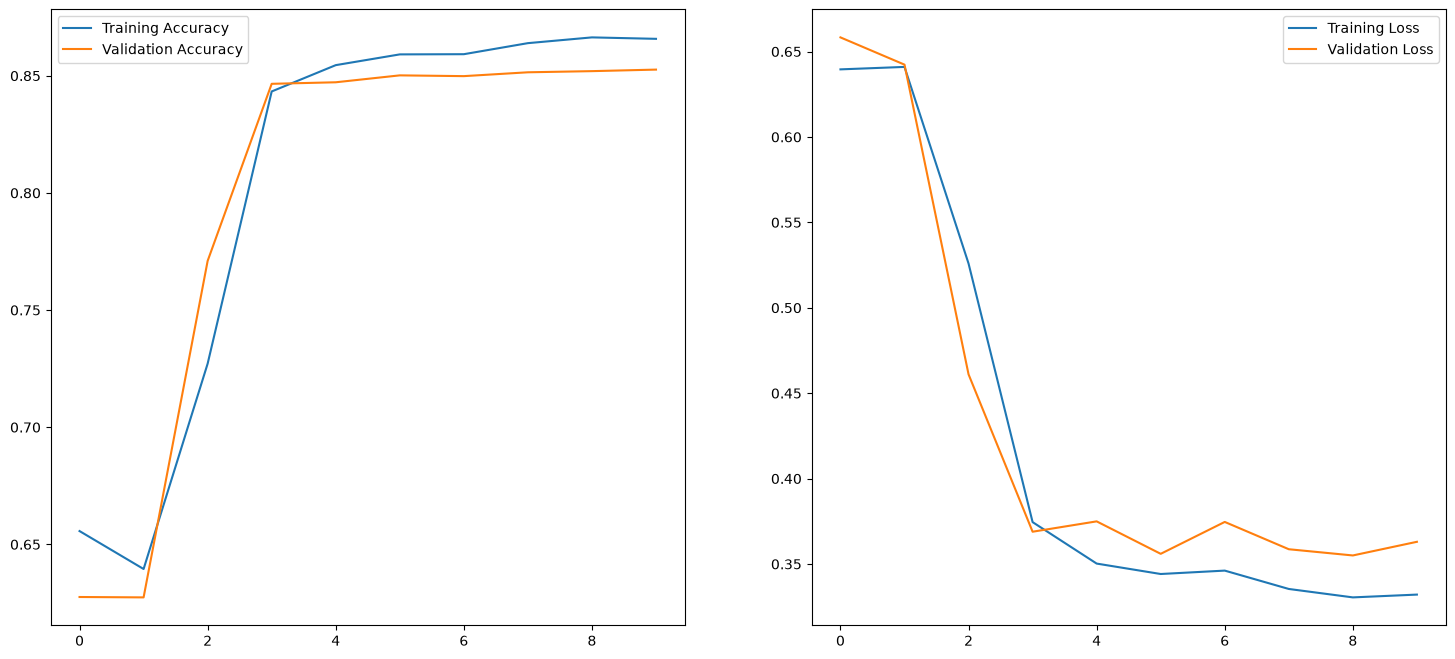

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(18,8))

axes[0].plot(history.history['accuracy'], label='Training Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Training Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].legend()

plt.show()

In [18]:
model.compile(
    loss='binary_crossentropy',
    optimizer='nadam',
    metrics=['accuracy'],
)

history = model.fit(
    X_train_full.values, y_train_full.values,
    epochs=10,
)

Epoch 1/10
953/953 ━━━━━━━━━━━━━━━━━━━━ 45s 45ms/step - accuracy: 0.8626 - loss: 0.3372
Epoch 2/10
953/953 ━━━━━━━━━━━━━━━━━━━━ 41s 43ms/step - accuracy: 0.8646 - loss: 0.3347
Epoch 3/10
953/953 ━━━━━━━━━━━━━━━━━━━━ 43s 45ms/step - accuracy: 0.8661 - loss: 0.3310
Epoch 4/10
953/953 ━━━━━━━━━━━━━━━━━━━━ 38s 40ms/step - accuracy: 0.8673 - loss: 0.3255
Epoch 5/10
953/953 ━━━━━━━━━━━━━━━━━━━━ 37s 39ms/step - accuracy: 0.8683 - loss: 0.3255
Epoch 6/10
953/953 ━━━━━━━━━━━━━━━━━━━━ 36s 37ms/step - accuracy: 0.8663 - loss: 0.3287
Epoch 7/10
953/953 ━━━━━━━━━━━━━━━━━━━━ 36s 38ms/step - accuracy: 0.8692 - loss: 0.3161
Epoch 8/10
953/953 ━━━━━━━━━━━━━━━━━━━━ 36s 38ms/step - accuracy: 0.8717 - loss: 0.3076
Epoch 9/10
953/953 ━━━━━━━━━━━━━━━━━━━━ 37s 38ms/step - accuracy: 0.8737 - loss: 0.3036
Epoch 10/10
953/953 ━━━━━━━━━━━━━━━━━━━━ 36s 38ms/step - accuracy: 0.8744 - loss: 0.3000


In [19]:
y_proba = model.predict(X_test.values)

239/239 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step


In [20]:
y_pred = np.where(y_proba > 0.5, 1, 0)
y_pred

array([[1],
       [1],
       [0],
       ...,
       [0],
       [1],
       [0]], shape=(7624, 1))

In [21]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.8614900314795383

In [22]:
for i in range(10):
    print(f'label: {y_test.iloc[i]}, prediction: {y_pred[i]}, review: {X_test.iloc[i]}')

label: 1, prediction: [1], review: Jbfhiighhjjjjjjnnnnnnnnnnnmmmmmmmmmmmmmmmmmmmmmm
label: 1, prediction: [1], review: برنامج حلو و يستاهل
label: 0, prediction: [0], review: ما انصحكم تنزلون التطبيق الانه ماعندهم مصداقيه في اخذ الطلبات وغير عن هذا مايردون عليك لو كان عندك مشكله ومصور الشاشه كيف خدمتهم اذا كان عندك مشكله يخلونك تنتظر على فاضي واتحدهم اذا كان كلامي غلط ما يستاهلون ولا نجمه حتى صفر وايد عليهم
label: 0, prediction: [0], review: افشل شركه
label: 0, prediction: [0], review: فاشل 🤬🤬
label: 0, prediction: [0], review: نغسي يوصل طلب بموعده 😡😡 دائما اقل تاخير ساعه ،جربنا برمضان وافطرنا بعد الاذان بساعه ونص وقلنا عذره ازمه جربنا عالعيد قلنا ازمه ، هلاء برضوا طلب اتاخر ساعه ونص ومافي ازمه ،،للاسف اهمال كبير
label: 1, prediction: [1], review: سهل جدا .... مرتب ويسهل عليكم البحث عن المطاعم ... ميزة التقيم تساعد في اختيار المطاعم
label: 0, prediction: [0], review: خدمة سيئة و عروض وهمية طلبت بأستخدام كود خصم و انتظرت اكثر من ساعتين و بعدها كلمت خدمة العملاء قاللي الطلب اتلغي لان استخ